In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
pd.set_option('display.max_columns',None)

In [3]:
df = pd.read_csv('smartphone_cleaned_v2.csv')

## Automatic Assessment

In [4]:
df.shape

(980, 24)

In [5]:
df.head()

,brand_name,model,price,rating,has_5g,has_nfc,has_ir_blaster,processor_name,processor_brand,num_cores,processor_speed,battery_capacity,fast_charging,ram_capacity,internal_memory,screen_size,resolution,refresh_rate,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory
0,oneplus,OnePlus 11 5G,54999,89.0,True,True,False,Snapdragon 8 Gen2,snapdragon,Octa Core,3.2,5000.0,100,12.0,256.0,6.70,1440 x 3216,120,3,1,android,50.0,16,0
1,oneplus,OnePlus Nord CE 2 Lite 5G,19989,81.0,True,False,False,Snapdragon 695,snapdragon,Octa Core,2.2,5000.0,33,6.0,128.0,6.59,1080 x 2412,120,3,1,android,64.0,16,1 TB
2,samsung,Samsung Galaxy A14 5G,16499,75.0,True,False,False,Exynos 1330,exynos,Octa Core,2.4,5000.0,15,4.0,64.0,6.60,1080 x 2408,90,3,1,android,50.0,13,1 TB
3,motorola,Motorola Moto G62 5G,14999,81.0,True,False,False,Snapdragon 695,snapdragon,Octa Core,2.2,5000.0,0,6.0,128.0,6.55,1080 x 2400,120,3,1,android,50.0,16,1 TB
4,realme,Realme 10 Pro Plus,24999,82.0,True,False,False,Dimensity 1080,dimensity,Octa Core,2.6,5000.0,67,6.0,128.0,6.70,1080 x 2412,120,3,1,android,108.0,16,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 980 entries, 0 to 979
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   brand_name            980 non-null    object 
 1   model                 980 non-null    object 
 2   price                 980 non-null    int64  
 3   rating                879 non-null    float64
 4   has_5g                980 non-null    bool   
 5   has_nfc               980 non-null    bool   
 6   has_ir_blaster        980 non-null    bool   
 7   processor_name        960 non-null    object 
 8   processor_brand       960 non-null    object 
 9   num_cores             974 non-null    object 
 10  processor_speed       938 non-null    float64
 11  battery_capacity      969 non-null    float64
 12  fast_charging         980 non-null    int64  
 13  ram_capacity          980 non-null    float64
 14  internal_memory       978 non-null    float64
 15  screen_size           9

In [7]:
# checking null Values in all columns
df.isnull().sum()

brand_name                0
model                     0
price                     0
rating                  101
has_5g                    0
has_nfc                   0
has_ir_blaster            0
processor_name           20
processor_brand          20
num_cores                 6
processor_speed          42
battery_capacity         11
fast_charging             0
ram_capacity              0
internal_memory           2
screen_size               0
resolution                0
refresh_rate              0
num_rear_cameras          0
num_front_cameras         0
os                        0
primary_camera_rear       0
primary_camera_front      4
extended_memory           0
dtype: int64

In [8]:
# brand name
df['brand_name'].value_counts()

brand_name
xiaomi       134
samsung      132
vivo         111
realme        97
oppo          88
motorola      52
apple         46
oneplus       42
poco          41
tecno         33
iqoo          32
infinix       29
huawei        16
google        14
nokia         13
honor         13
itel          10
sony           9
asus           7
nubia          6
nothing        5
jio            4
lava           4
gionee         3
letv           3
ikall          3
lg             3
oukitel        3
redmi          3
micromax       3
doogee         2
lenovo         2
zte            2
lyf            2
royole         2
tesla          1
leeco          1
duoqin         1
cola           1
blu            1
vertu          1
leitz          1
cat            1
tcl            1
sharp          1
blackview      1
Name: count, dtype: int64

<Axes: xlabel='brand_name'>

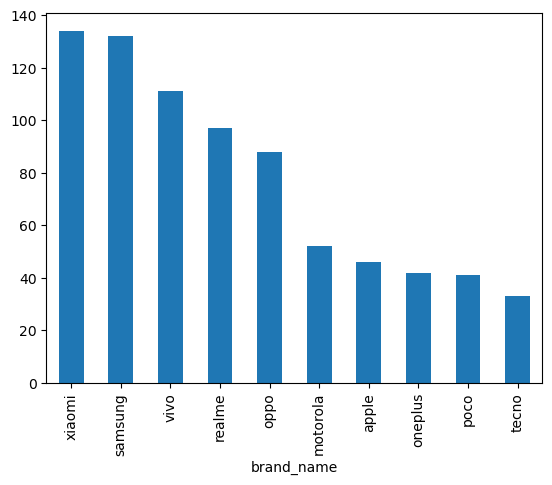

In [9]:
# Top 10 Phone brands
df['brand_name'].value_counts().head(10).plot(kind='bar')

In [10]:
# price col
df['price'].describe()

count       980.000000
mean      32520.504082
std       39531.812669
min        3499.000000
25%       12999.000000
50%       19994.500000
75%       35491.500000
max      650000.000000
Name: price, dtype: float64

<Axes: xlabel='price', ylabel='Count'>

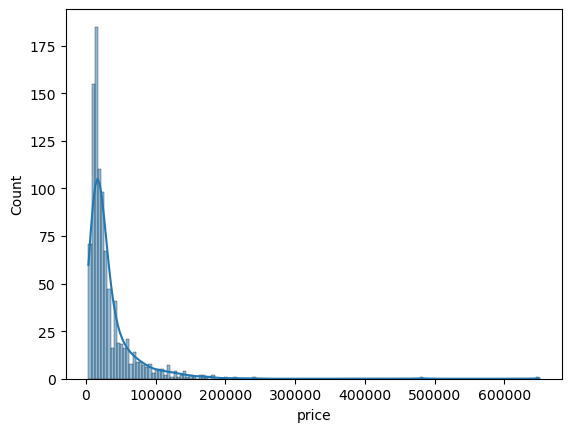

In [11]:
sns.histplot(df['price'],kde=True)

In [12]:
df['price'].skew()
# Data is highly skewed

np.float64(6.591790999665567)

<Axes: ylabel='price'>

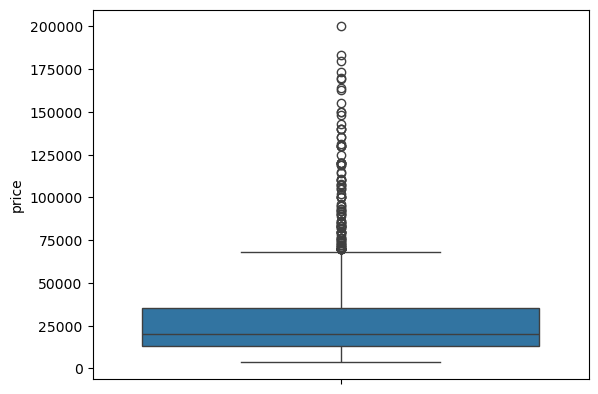

In [13]:
# checking outliers in price col
sns.boxplot(df[df['price']<200000]['price'])

In [14]:
df[df['price']>200000]

,brand_name,model,price,rating,has_5g,has_nfc,has_ir_blaster,processor_name,processor_brand,num_cores,processor_speed,battery_capacity,fast_charging,ram_capacity,internal_memory,screen_size,resolution,refresh_rate,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory
427,vertu,Vertu Signature Touch,650000,62.0,False,True,False,Snapdragon 801,snapdragon,Octa Core,1.50,2275.0,-1,2.0,64.0,4.70,1080 x 1920,60,1,1,android,13.0,2.1,0
478,huawei,Huawei Mate 50 RS Porsche Design,239999,81.0,False,True,True,Snapdragon 8+ Gen1,snapdragon,Octa Core,3.20,4700.0,66,12.0,512.0,6.74,1212 x 2616,120,3,1,other,50.0,13,256 GB
887,xiaomi,Xiaomi Redmi K20 Pro Signature Edition,480000,88.0,False,True,False,Snapdragon 855,snapdragon,Octa Core,2.80,4000.0,27,8.0,256.0,6.39,1080 x 2340,60,3,1,android,48.0,20,0
951,huawei,Huawei Mate 30 RS Porsche Design,214990,NaN,True,True,True,Kirin 990,kirin,Octa Core,2.86,4500.0,0,12.0,512.0,6.53,1176 x 2400,60,4,2,android,40.0,32,256 GB


In [15]:
# checking for null value in price col
df['price'].isnull().sum()

np.int64(0)

In [16]:
# rating col
df['rating'].describe()

count    879.000000
mean      78.258248
std        7.402854
min       60.000000
25%       74.000000
50%       80.000000
75%       84.000000
max       89.000000
Name: rating, dtype: float64

<Axes: xlabel='rating', ylabel='Count'>

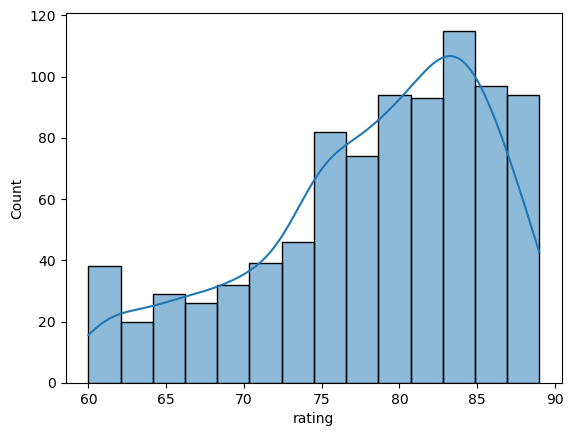

In [17]:
sns.histplot(df['rating'],kde=True)

In [18]:
#checking skewness
df['rating'].skew()

np.float64(-0.6989993034105535)

<Axes: ylabel='rating'>

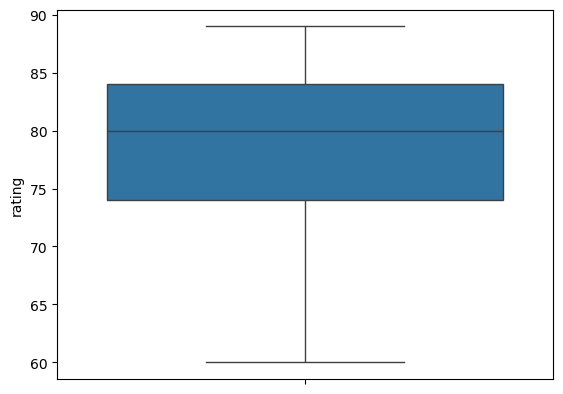

In [19]:
# checking outliers
sns.boxplot(df['rating'])

In [20]:
# checking for null value in rating col
df['rating'].isnull().sum()

np.int64(101)

<Axes: xlabel='has_5g'>

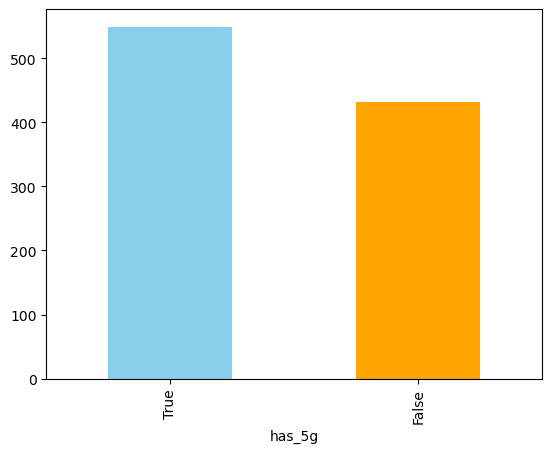

In [21]:
# has_5g
df['has_5g'].value_counts().plot(kind='bar',color=['skyblue','orange'])

In [22]:
df['has_5g'].value_counts()

has_5g
True     549
False    431
Name: count, dtype: int64

<Axes: xlabel='has_nfc'>

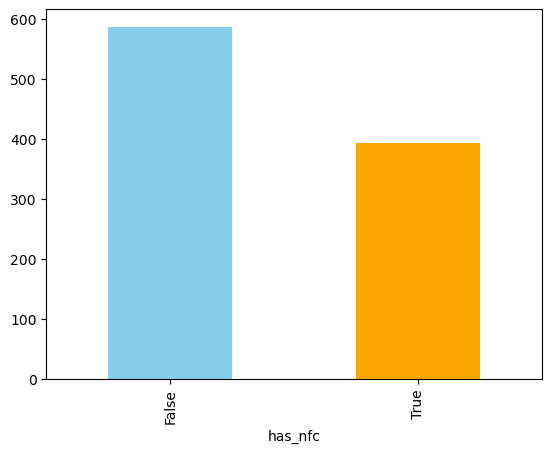

In [23]:
# has_nfc
df['has_nfc'].value_counts().plot(kind='bar',color=['skyblue','orange'])

In [24]:
df['has_nfc'].value_counts()

has_nfc
False    587
True     393
Name: count, dtype: int64

<Axes: xlabel='has_ir_blaster'>

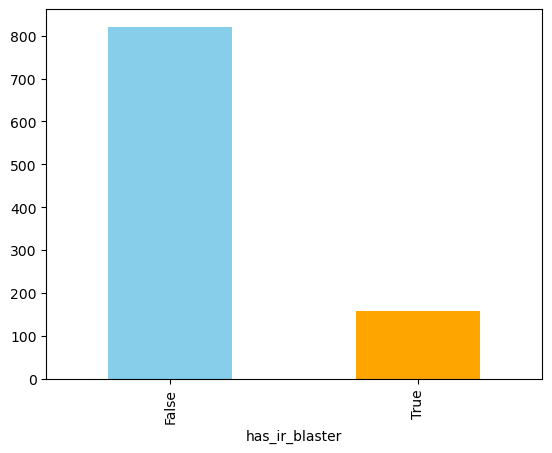

In [25]:
# has_ir_blaster
df['has_ir_blaster'].value_counts().plot(kind='bar',color=['skyblue','orange'])

In [26]:
df['has_ir_blaster'].value_counts()

has_ir_blaster
False    821
True     159
Name: count, dtype: int64

## Round 2 Data Cleaning

In [27]:
# replacing genuine processor_brand inplace of incorrect values
df['processor_brand'] = df['processor_brand'].str.replace('sanpdragon','snapdragon')
df['processor_brand'] = df['processor_brand'].str.replace('apple','bionic')
df['processor_brand'] = df['processor_brand'].str.replace('samsung','exynos')

In [28]:
temp_df = df[df['processor_brand'] == 'qualcomm']

In [29]:
df.loc[temp_df.index, 'processor_brand'] = 'snapdragon'

In [30]:
temp_df = df[df['processor_brand'] == 'a13']

In [31]:
df.loc[temp_df.index, 'processor_brand'] = 'bionic'

In [32]:
df['processor_brand'].value_counts()

processor_brand
snapdragon    413
helio         201
dimensity     177
exynos         50
bionic         45
unisoc         26
tiger          24
google          9
kirin           7
spreadtrum      4
sc9863a         2
fusion          1
mediatek        1
Name: count, dtype: int64

In [33]:
# null values in processor_brand
df[df['processor_brand'].isnull()]

,brand_name,model,price,rating,has_5g,has_nfc,has_ir_blaster,processor_name,processor_brand,num_cores,processor_speed,battery_capacity,fast_charging,ram_capacity,internal_memory,screen_size,resolution,refresh_rate,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory
118,tesla,Tesla Pi Phone,69999,83.0,True,True,False,NaN,NaN,Octa Core,NaN,5000.0,120,16.0,512.0,6.73,1080 x 2448,165,3,1,android,50.0,32,0
143,jio,Jio Phone 3,4499,NaN,False,False,False,NaN,NaN,Quad Core,1.4,2800.0,-1,2.0,64.0,5.00,720 x 1280,60,1,1,android,5.0,2,128 GB
187,ikall,iKall Z19 Pro,8099,60.0,False,False,False,NaN,NaN,Quad Core,1.6,5000.0,-1,4.0,64.0,6.50,720 x 1600,60,1,1,android,13.0,8,128 GB
200,samsung,Samsung Galaxy A13,14450,75.0,False,False,False,NaN,NaN,Octa Core,2.0,5000.0,25,4.0,64.0,6.60,1080 x 2408,60,4,1,android,50.0,8,1 TB
307,samsung,Samsung Galaxy A13 (4GB RAM + 128GB),14999,75.0,False,False,False,NaN,NaN,Octa Core,2.0,5000.0,25,4.0,128.0,6.60,1080 x 2408,60,4,1,android,50.0,8,1 TB
313,itel,itel S16 Pro,6990,NaN,False,False,False,NaN,NaN,Quad Core,1.3,4000.0,-1,2.0,32.0,6.60,1600 x 720,60,3,1,android,8.0,8,32 GB
490,samsung,Samsung Galaxy A15,15990,63.0,False,False,False,NaN,NaN,Octa Core,NaN,5000.0,0,6.0,64.0,6.50,720 x 1600,60,3,1,android,48.0,8,1 TB
523,samsung,Samsung Galaxy F14,14990,67.0,False,True,False,NaN,NaN,Octa Core,NaN,5000.0,25,4.0,64.0,6.62,2408 x 1080,60,3,1,android,50.0,16,1 TB
575,samsung,Samsung Galaxy A13 (6GB RAM + 128GB),16499,78.0,False,False,False,NaN,NaN,Octa Core,2.0,5000.0,25,6.0,128.0,6.60,1080 x 2408,60,4,1,android,50.0,8,1 TB
733,ikall,iKall Z19,7999,61.0,False,False,False,NaN,NaN,Quad Core,1.6,5000.0,-1,4.0,32.0,6.50,720 x 1600,60,1,1,android,20.0,13,128 GB


In [34]:
# checking num_cores values:
df['num_cores'].value_counts()

num_cores
Octa Core    899
Hexa Core     39
Quad Core     36
Name: count, dtype: int64

In [35]:
# processor_speed
df['processor_speed'].describe()

count    938.000000
mean       2.427217
std        0.464090
min        1.200000
25%        2.050000
50%        2.300000
75%        2.840000
max        3.220000
Name: processor_speed, dtype: float64

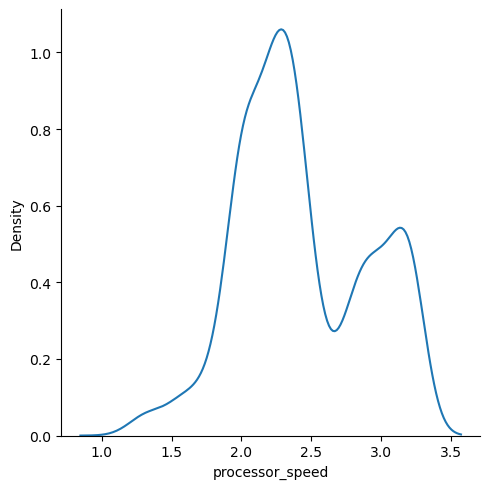

In [36]:
sns.displot(kind='kde',data=df,x='processor_speed')

In [37]:
df['processor_speed'].skew()
# Data is almost normally skewed

np.float64(0.18833557463624606)

<Axes: ylabel='processor_speed'>

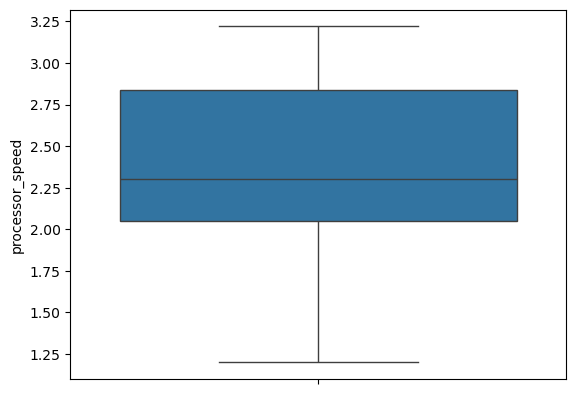

In [38]:
# checking Outliers 
sns.boxplot(df['processor_speed'])

In [39]:
# battery_capacity
df['battery_capacity'].describe()

count      969.000000
mean      4817.748194
std       1009.540054
min       1821.000000
25%       4500.000000
50%       5000.000000
75%       5000.000000
max      22000.000000
Name: battery_capacity, dtype: float64

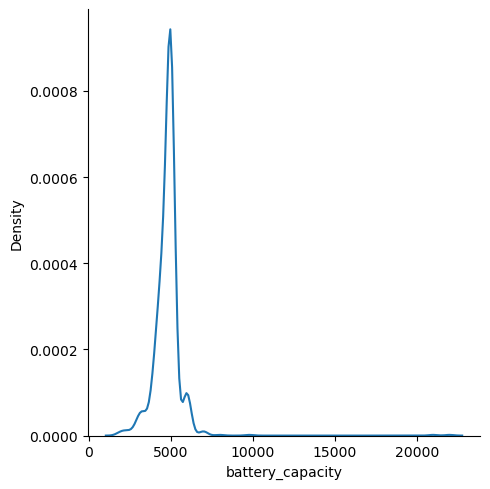

In [40]:
sns.displot(kind='kde',data=df,x='battery_capacity')

In [41]:
# Checking Outliers
df[df['battery_capacity'] > 7000]

,brand_name,model,price,rating,has_5g,has_nfc,has_ir_blaster,processor_name,processor_brand,num_cores,processor_speed,battery_capacity,fast_charging,ram_capacity,internal_memory,screen_size,resolution,refresh_rate,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory
391,oukitel,Oukitel WP19,29990,84.0,False,True,False,Helio G95,helio,Octa Core,2.0,21000.0,33,8.0,256.0,6.78,1080 x 2400,60,3,1,android,64.0,16,Not Specified
599,oukitel,Oukitel WP21,22990,82.0,False,False,False,Helio G99,helio,Octa Core,2.2,9800.0,66,12.0,256.0,6.78,1080 x 2400,120,3,1,Not Specified,64.0,Main,0
843,doogee,Doogee V Max,45999,88.0,True,False,False,Dimensity 1080,dimensity,Octa Core,2.6,22000.0,33,12.0,256.0,6.58,1080 x 2408,120,3,1,android,108.0,32,2 TB
966,oukitel,Oukitel WP9,25899,72.0,False,True,False,Helio P60,helio,Octa Core,2.0,8000.0,-1,6.0,128.0,5.86,720 x 1520,60,3,1,android,16.0,8,Not Specified


In [42]:
# Fast Charging
df['fast_charging'].describe()

count    980.000000
mean      36.048980
std       35.948034
min       -1.000000
25%       15.000000
50%       30.000000
75%       65.000000
max      240.000000
Name: fast_charging, dtype: float64

In [43]:
# Function
def fast(row):

  if row['fast_charging'] == -1:
    return 0
  else:
    return 1

In [44]:
x = df.apply(fast,axis=1)
df.insert(12,'fast_charging_available',x)

In [45]:
# give 0 and 1 value if fast_charging_available
df['fast_charging'] = df['fast_charging'].apply(lambda x:np.nan if x == 0 or x == -1 else x)

In [46]:
df['fast_charging_available'].value_counts()

fast_charging_available
1    837
0    143
Name: count, dtype: int64

In [47]:
# ram_capacity
df['ram_capacity'].value_counts()

ram_capacity
8.0     339
6.0     234
4.0     217
12.0     86
3.0      54
2.0      32
16.0      9
1.0       7
18.0      2
Name: count, dtype: int64

In [48]:
# internal_memory
temp_df = df[df['internal_memory'].isnull()]

In [49]:
# replacing nan with default value of 4 ram & 64 internal
df.loc[temp_df.index,['ram_capacity','internal_memory']] = [[4,64],[4,64]]

In [50]:
df['internal_memory'].value_counts()

internal_memory
128.0     523
64.0      193
256.0     157
32.0       67
512.0      22
16.0       12
1024.0      5
8.0         1
Name: count, dtype: int64

In [51]:
# screen_size
df['screen_size'].describe()

count    980.000000
mean       6.536765
std        0.349162
min        3.540000
25%        6.500000
50%        6.580000
75%        6.670000
max        8.030000
Name: screen_size, dtype: float64

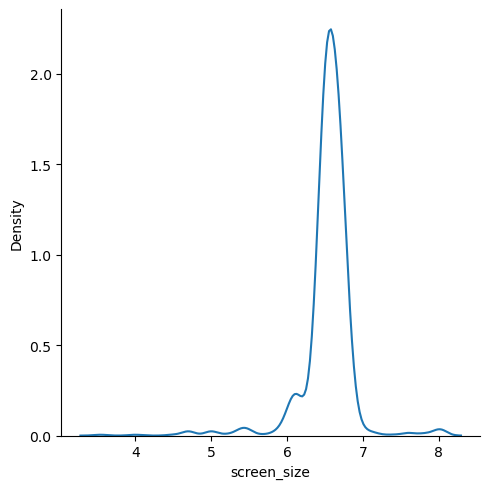

In [52]:
sns.displot(kind='kde',data=df,x='screen_size')

In [53]:
df['screen_size'].skew()
# data is negatively skewed

np.float64(-2.11619902968816)

<Axes: ylabel='screen_size'>

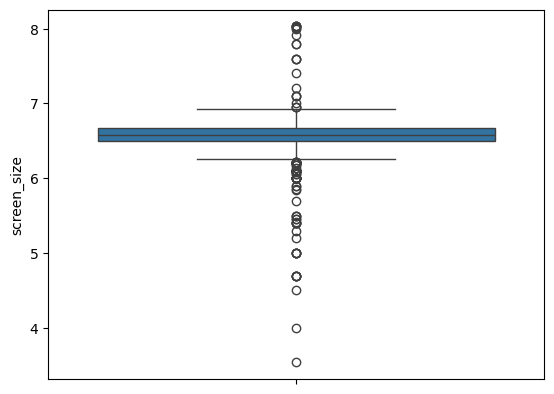

In [54]:
# checking Outliers
sns.boxplot(df['screen_size'])

In [55]:
# extented_memory
df['extended_memory'].value_counts()

extended_memory
0                385
1 TB             262
512 GB           116
256 GB           104
Not Specified     88
128 GB            10
2 TB               8
32 GB              3
64 GB              3
1000 GB            1
Name: count, dtype: int64

In [56]:
# Added new feature is extended_memory_available
df['extended_memory_available'] = df['extended_memory'].apply(lambda x:0 if x == '0' else 1)

In [57]:
# Function
def extended_extractor(row):

  if row['extended_memory_available'] == 0:
    return np.nan
  else:
    if row['extended_memory'] == '1 TB':
      return 1024
    elif row['extended_memory'] == '512 GB':
      return 512
    elif row['extended_memory'] == '256 GB':
      return 256
    elif row['extended_memory'] == 'Not Specified':
      return np.nan
    elif row['extended_memory'] == 'Memory Card (Hybrid)':
      return np.nan
    elif row['extended_memory'] == '128 GB':
      return 128
    elif row['extended_memory'] == '2 TB':
      return 2048
    elif row['extended_memory'] == '32 GB':
      return 32
    elif row['extended_memory'] == '64 GB':
      return 64
    elif row['extended_memory'] == '1000 GB':
      return 1000

In [58]:
# Function
def extended_extractor(row):

  if row['extended_memory_available'] == 0:
    return np.nan
  else:
    if row['extended_memory'] == 'Not Specified':
      return np.nan
    elif row['extended_memory'] == 'Memory Card (Hybrid)':
      return np.nan
    else:
      return row['extended_memory']

In [59]:
df['extended_memory'].value_counts()

extended_memory
0                385
1 TB             262
512 GB           116
256 GB           104
Not Specified     88
128 GB            10
2 TB               8
32 GB              3
64 GB              3
1000 GB            1
Name: count, dtype: int64

In [60]:
# Removing TB & GB extra char
x = df.apply(extended_extractor,axis=1).str.replace('\u2009',' ').str.split(' ').str.get(0)

In [61]:
df['extended_upto'] = x

In [62]:
# Function
def transform(text):

  if text == '1':
    return '1024'
  elif text == '2':
    return '2048'
  elif text == '1000':
    return '1024'
  else:
    return text

In [63]:
df['extended_upto'] = df['extended_upto'].apply(transform)

In [64]:
df['extended_upto'].value_counts()

extended_upto
1024    263
512     116
256     104
128      10
2048      8
32        3
64        3
Name: count, dtype: int64

In [65]:
# os
df['os'].value_counts()

os
android          910
ios               46
Not Specified     14
other             10
Name: count, dtype: int64

In [66]:
# Function
def os_transform(text):

  if 'Memory' in text:
    return np.nan
  elif 'android' in text:
    return text
  elif 'ios' in text:
    return text
  else:
    return 'other'

In [67]:
df['os'] = df['os'].apply(os_transform)